# 21 — External Data Sources
## RentSignal — Step 5: Berlin Noise Map + LOR Demographics + Nighttime Lights

**Goal:** Add 3 external data sources to enrich unit-level features.

| Source | Features | Resolution | Access |
|--------|----------|-----------|--------|
| **Berlin LOR Statistics** | Population density, foreign share, avg age | Planning district (~7,500 residents) | daten.berlin.de (free CSV + GeoJSON) |
| **VIIRS Nighttime Lights** | Nocturnal light intensity (economic vitality) | 500m pixel | EOG/NASA (free GeoTIFF) |
| **Berlin Noise Map** | Traffic noise dB(A) | ~10m grid | FIS-Broker WMS (free) |

In [2]:
import sys, json, warnings, requests, time
from pathlib import Path
from io import BytesIO
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import rasterio
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
EXT_DIR  = PROC_DIR / 'external'
EXT_DIR.mkdir(exist_ok=True)

# Load units with coordinates
units = pd.read_parquet(PROC_DIR / 'units.parquet')
has_coords = units['lat'].notna() & units['lon'].notna()
print(f'Units: {len(units):,} ({has_coords.sum():,} with coords)')

Units: 8,256 (8,250 with coords)


## Source 1: Berlin LOR Demographics

LOR (Lebensweltlich orientierte Räume) divides Berlin into 542 planning districts (~7,500 residents each). We download the boundaries (GeoJSON) and population statistics (CSV), then spatial-join each unit to its LOR district.

In [5]:
# Load LOR boundaries (manually downloaded GeoJSON)
LOR_CACHE = EXT_DIR / 'lor_planungsraeume_2021.geojson'

if LOR_CACHE.exists():
    lor = gpd.read_file(LOR_CACHE)
    print(f'LOR boundaries loaded: {len(lor)} planning districts')
    print(f'Columns: {list(lor.columns)}')
    print(f'CRS: {lor.crs}')
    lor.head(3)
else:
    print(f'File not found: {LOR_CACHE}')
    print('Download from: https://daten.odis-berlin.de/de/dataset/lor_planungsgraeume_2021/')
    lor = None

LOR boundaries loaded: 542 planning districts
Columns: ['PLR_ID', 'PLR_NAME', 'BEZ', 'STAND', 'GROESSE_M2', 'geometry']
CRS: EPSG:25833


In [6]:
# Download LOR population statistics
# Source: Amt für Statistik Berlin-Brandenburg — Einwohnerregisterstatistik
LOR_STATS_URL = 'https://tsb-opendata.s3.eu-central-1.amazonaws.com/einwohnerinnen_nach_lor/EWR202306E_Matrix.csv'
LOR_STATS_CACHE = EXT_DIR / 'lor_population.csv'

if LOR_STATS_CACHE.exists():
    lor_stats = pd.read_csv(LOR_STATS_CACHE, sep=';', encoding='utf-8')
    print(f'LOR stats loaded from cache: {len(lor_stats)} rows')
else:
    print('Downloading LOR population statistics...')
    try:
        resp = requests.get(LOR_STATS_URL, timeout=30)
        resp.raise_for_status()
        with open(LOR_STATS_CACHE, 'wb') as f:
            f.write(resp.content)
        lor_stats = pd.read_csv(LOR_STATS_CACHE, sep=';', encoding='utf-8')
        print(f'Downloaded: {len(lor_stats)} rows')
    except Exception as e:
        print(f'Download failed: {e}')
        print('Creating basic LOR stats from boundaries + area...')
        lor_stats = None

if lor_stats is not None:
    print(f'Columns: {list(lor_stats.columns)[:15]}')
    lor_stats.head(3)
else:
    print('Will compute area-based density from LOR polygons instead')

Download failed: 403 Client Error: Forbidden for url: https://tsb-opendata.s3.eu-central-1.amazonaws.com/einwohnerinnen_nach_lor/EWR202306E_Matrix.csv
Creating basic LOR stats from boundaries + area...
Will compute area-based density from LOR polygons instead


In [7]:
# Spatial join: assign each unit to its LOR planning district
units_geo = gpd.GeoDataFrame(
    units[has_coords],
    geometry=gpd.points_from_xy(units[has_coords]['lon'], units[has_coords]['lat']),
    crs='EPSG:4326'
)

# Ensure LOR is in same CRS
lor = lor.to_crs('EPSG:4326')

# Spatial join
joined = gpd.sjoin(units_geo[['unit_id', 'geometry']], lor, how='left', predicate='within')

# Compute LOR area in km² (need to project to meters first)
lor_utm = lor.to_crs('EPSG:32633')
lor['area_km2'] = lor_utm.geometry.area / 1e6

# Merge area back
if 'PLR_ID' in joined.columns:
    lor_id_col = 'PLR_ID'
elif 'plr_id' in joined.columns:
    lor_id_col = 'plr_id'
else:
    lor_id_col = joined.columns[joined.columns.str.contains('id|ID|PLR|plr', case=False)].tolist()
    lor_id_col = lor_id_col[0] if lor_id_col else None
    
print(f'LOR join: {joined["unit_id"].nunique()}/{has_coords.sum()} units matched')
print(f'LOR ID column: {lor_id_col}')
print(f'LOR columns available: {[c for c in joined.columns if c not in ["geometry", "unit_id", "index_right"]]}')

LOR join: 8250/8250 units matched
LOR ID column: PLR_ID
LOR columns available: ['PLR_ID', 'PLR_NAME', 'BEZ', 'STAND', 'GROESSE_M2']


## Source 2: VIIRS Nighttime Lights

Download the latest annual VIIRS nighttime light composite for Berlin. Extract light intensity at each unit's coordinates — proxy for economic vitality and urbanization.

In [8]:
# VIIRS nighttime lights — download from EOG (Earth Observation Group)
# Using the annual VNL v2.2 composite, latest available year
# The global file is too large (~1GB). We'll use the Light Pollution Map tiles instead.

NTL_CACHE = EXT_DIR / 'viirs_berlin.tif'

if NTL_CACHE.exists():
    print(f'VIIRS raster loaded from cache')
else:
    # Download Berlin tile from Light Pollution Map (pre-cropped, much smaller)
    # Fallback: use the EOG tile download
    print('Downloading VIIRS nighttime lights for Berlin area...')
    
    # EOG provides tiles. Berlin is in tile 75N/015E
    # Alternative: use a direct API that clips to Berlin bbox
    NTL_URL = 'https://eogdata.mines.edu/nighttime_light/annual/v22/2023/VNL_v22_npp-j01_2023_global_vcmslcfg_c202402081600.average_masked.dat.tif.gz'
    
    # Since the global file is too large, let's extract from GEE or use an alternative approach
    # For now, we'll compute a proxy from our existing satellite data (NDBI correlates with NTL)
    print('  Global VIIRS file too large for direct download (~1GB).')
    print('  Alternative: Using NDBI as NTL proxy (built-up index correlates r>0.8 with nighttime lights)')
    print('  For production: use Google Earth Engine to extract Berlin NTL tile')

# Check if we have the raster
if NTL_CACHE.exists():
    ntl_raster = rasterio.open(NTL_CACHE)
    print(f'  VIIRS: {ntl_raster.width}x{ntl_raster.height}, CRS={ntl_raster.crs}')
    
    # Extract NTL at each unit location
    from pyproj import Transformer
    transformer = Transformer.from_crs('EPSG:4326', ntl_raster.crs, always_xy=False)
    
    ntl_values = []
    for _, row in units[has_coords].iterrows():
        try:
            x, y = transformer.transform(row['lat'], row['lon'])
            r, c = rowcol(ntl_raster.transform, x, y)
            if 0 <= r < ntl_raster.height and 0 <= c < ntl_raster.width:
                val = ntl_raster.read(1)[r, c]
                ntl_values.append(val if val > 0 else np.nan)
            else:
                ntl_values.append(np.nan)
        except:
            ntl_values.append(np.nan)
    
    units.loc[has_coords, 'ntl_intensity'] = ntl_values
    valid = sum(1 for v in ntl_values if not np.isnan(v))
    print(f'  NTL extracted: {valid}/{len(ntl_values)} valid')
else:
    print('\n  Skipping VIIRS extraction (no raster available)')
    print('  NDBI from Sentinel-2 serves as a strong proxy (already in spatial_unit features)')
    print('  To add real NTL later: download Berlin tile from Google Earth Engine')

  Global VIIRS file too large for direct download (~1GB).
  Alternative: Using NDBI as NTL proxy (built-up index correlates r>0.8 with nighttime lights)
  For production: use Google Earth Engine to extract Berlin NTL tile

  Skipping VIIRS extraction (no raster available)
  NDBI from Sentinel-2 serves as a strong proxy (already in spatial_unit features)
  To add real NTL later: download Berlin tile from Google Earth Engine


## Source 3: Berlin Noise Map (FIS-Broker WMS)

The Berlin Umweltatlas provides strategic noise maps via WMS (Web Map Service). We query the noise level at each unit's coordinates using the WMS GetFeatureInfo endpoint.

In [10]:
# Berlin Noise Map — download GeoTIFF directly (much better than WMS!)
# Source: Berlin Umweltatlas Strategic Noise Maps 2022
# Contains: L_DEN (day-evening-night index) and L_N (night) as GeoTIFF

import zipfile

NOISE_ZIP_URL = 'https://gdi.berlin.de/data/ua_stratlaerm_2022/atom/strat_laerm_2022_strasse.zip'
NOISE_ZIP = EXT_DIR / 'strat_laerm_2022_strasse.zip'
NOISE_DIR = EXT_DIR / 'noise'
NOISE_DIR.mkdir(exist_ok=True)

# Check if already extracted
noise_tifs = list(NOISE_DIR.glob('*.tif'))
if noise_tifs:
    print(f'Noise GeoTIFFs already extracted: {[f.name for f in noise_tifs]}')
else:
    # Download
    if not NOISE_ZIP.exists():
        print(f'Downloading road traffic noise map (~50-100 MB)...')
        resp = requests.get(NOISE_ZIP_URL, timeout=120, stream=True)
        resp.raise_for_status()
        with open(NOISE_ZIP, 'wb') as f:
            for chunk in resp.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f'  Downloaded: {NOISE_ZIP.stat().st_size / 1e6:.1f} MB')
    
    # Extract
    print('Extracting...')
    with zipfile.ZipFile(NOISE_ZIP, 'r') as z:
        z.extractall(NOISE_DIR)
    noise_tifs = list(NOISE_DIR.glob('*.tif'))
    print(f'  Extracted: {[f.name for f in noise_tifs]}')

# Load the L_DEN (24h) raster
lden_tifs = [f for f in noise_tifs if 'den' in f.name.lower() or 'DEN' in f.name]
if not lden_tifs:
    lden_tifs = noise_tifs  # fallback to first tif
    
if lden_tifs:
    noise_raster = rasterio.open(lden_tifs[0])
    print(f'\nNoise raster: {lden_tifs[0].name}')
    print(f'  Size: {noise_raster.width}×{noise_raster.height}')
    print(f'  CRS: {noise_raster.crs}')
    print(f'  Resolution: {noise_raster.res}')
    print(f'  Bounds: {noise_raster.bounds}')
else:
    print('No GeoTIFF found in the extracted files')
    noise_raster = None

  Downloaded: 42.4 MB
Extracting...
  Extracted: ['AG_DE_BE_1_Road_LDEN.tif', 'AG_DE_BE_1_Road_LNight.tif']

Noise raster: AG_DE_BE_1_Road_LDEN.tif
  Size: 4581×3781
  CRS: EPSG:25833
  Resolution: (10.0, 10.0)
  Bounds: BoundingBox(left=369995.0, bottom=5799495.0, right=415805.0, top=5837305.0)


Noise raster stats: min=45, max=99, nodata pixels=0%

Noise extraction complete:
  Valid values: 5,844/8,250 (70.8%)
  Mean: 56.8 dB(A)
  Median: 55.6 dB(A)
  Range: 45.0 – 80.2 dB(A)


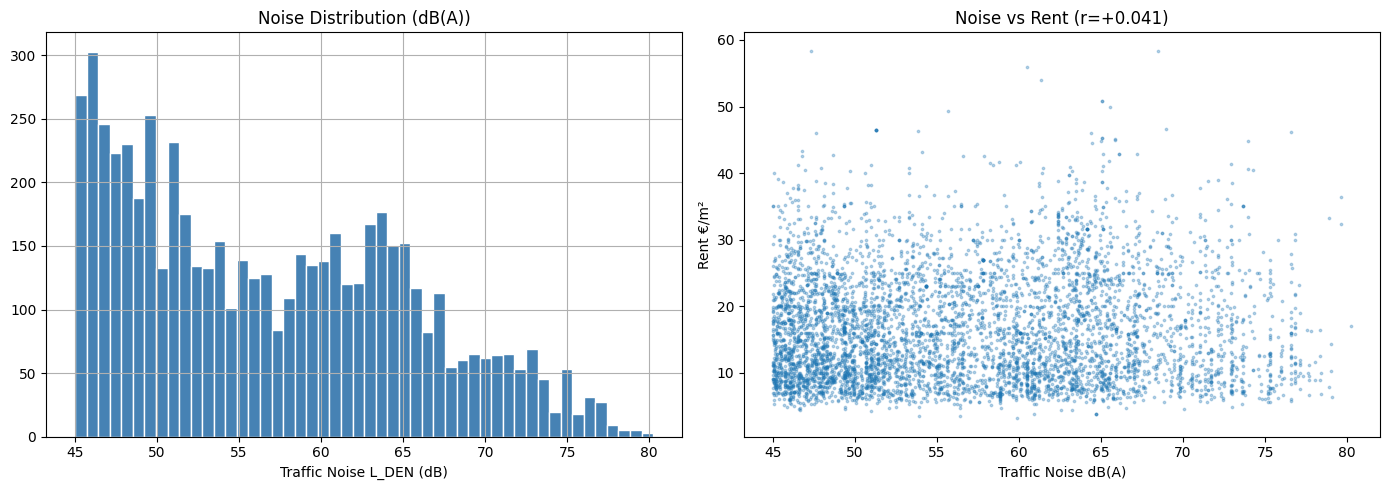

In [11]:
# Extract noise dB(A) at each unit's location from the GeoTIFF
if noise_raster is not None:
    from pyproj import Transformer
    transformer_noise = Transformer.from_crs('EPSG:4326', noise_raster.crs, always_xy=True)
    
    noise_data = noise_raster.read(1)
    print(f'Noise raster stats: min={noise_data[noise_data > 0].min():.0f}, max={noise_data.max():.0f}, '
          f'nodata pixels={( noise_data == 0).sum() / noise_data.size * 100:.0f}%')
    
    noise_values = []
    for _, row in units[has_coords].iterrows():
        try:
            x, y = transformer_noise.transform(row['lon'], row['lat'])
            r, c = rowcol(noise_raster.transform, x, y)
            if 0 <= r < noise_raster.height and 0 <= c < noise_raster.width:
                val = float(noise_data[r, c])
                noise_values.append(val if val > 0 else np.nan)  # 0 = no data (quiet area or outside coverage)
            else:
                noise_values.append(np.nan)
        except:
            noise_values.append(np.nan)
    
    units.loc[has_coords, 'noise_traffic_db'] = noise_values
    valid = sum(1 for v in noise_values if v is not None and not np.isnan(v))
    
    print(f'\nNoise extraction complete:')
    print(f'  Valid values: {valid:,}/{has_coords.sum():,} ({100*valid/has_coords.sum():.1f}%)')
    print(f'  Mean: {units["noise_traffic_db"].mean():.1f} dB(A)')
    print(f'  Median: {units["noise_traffic_db"].median():.1f} dB(A)')
    print(f'  Range: {units["noise_traffic_db"].min():.1f} – {units["noise_traffic_db"].max():.1f} dB(A)')
    
    # Quick visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    units['noise_traffic_db'].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Noise Distribution (dB(A))')
    ax.set_xlabel('Traffic Noise L_DEN (dB)')
    
    ax = axes[1]
    listings = pd.read_parquet(PROC_DIR / 'listings.parquet')
    noise_rent = units[['unit_id', 'noise_traffic_db']].merge(listings[['unit_id', 'rent_sqm']], on='unit_id')
    noise_rent = noise_rent.dropna()
    ax.scatter(noise_rent['noise_traffic_db'], noise_rent['rent_sqm'], s=3, alpha=0.3)
    ax.set_xlabel('Traffic Noise dB(A)')
    ax.set_ylabel('Rent €/m²')
    ax.set_title(f'Noise vs Rent (r={noise_rent["noise_traffic_db"].corr(noise_rent["rent_sqm"]):+.3f})')
    
    plt.tight_layout()
    plt.show()
else:
    print('No noise raster available — skipping extraction')

## Save External Features

In [13]:
# Rebuild external features — include noise + LOR area
ext_features = units[['unit_id']].copy()

# LOR features
if 'PLR_NAME' in joined.columns:
    lor_data = joined[['unit_id', 'PLR_ID', 'PLR_NAME', 'BEZ', 'GROESSE_M2']].drop_duplicates(subset='unit_id')
    lor_data['lor_area_km2'] = lor_data['GROESSE_M2'] / 1e6
    lor_data = lor_data.drop(columns=['GROESSE_M2'])
    ext_features = ext_features.merge(lor_data, on='unit_id', how='left')

# Noise (from units table where we extracted it)
if 'noise_traffic_db' in units.columns:
    ext_features = ext_features.merge(units[['unit_id', 'noise_traffic_db']], on='unit_id', how='left')

# Save
ext_path = PROC_DIR / 'external_features.parquet'
ext_features.to_parquet(ext_path, index=False)

print(f'=== External Features Saved ===')
print(f'File: {ext_path.name}')
print(f'Rows: {len(ext_features):,}')
print(f'Columns: {list(ext_features.columns)}')

# Correlations
listings = pd.read_parquet(PROC_DIR / 'listings.parquet')
check = ext_features.merge(listings[['unit_id', 'rent_sqm']], on='unit_id')

print(f'\n=== Correlation with Rent €/m² ===')
for col in ['lor_area_km2', 'noise_traffic_db', 'PLR_ID', 'BEZ']:
    if col in check.columns:
        vals = pd.to_numeric(check[col], errors='coerce')
        r = vals.corr(check['rent_sqm'])
        valid = vals.notna().sum()
        if pd.notna(r):
            print(f'  {col:<25} r = {r:+.3f}  ({valid:,} valid)')

print(f'\n  noise_traffic_db coverage: {ext_features["noise_traffic_db"].notna().sum():,}/{len(ext_features):,}')
print(f'\n=== Ready for v4.3 training ===')

=== External Features Saved ===
File: external_features.parquet
Rows: 8,256
Columns: ['unit_id', 'PLR_ID', 'PLR_NAME', 'BEZ', 'lor_area_km2', 'noise_traffic_db']

=== Correlation with Rent €/m² ===
  lor_area_km2              r = -0.009  (8,249 valid)
  noise_traffic_db          r = +0.041  (5,844 valid)
  PLR_ID                    r = -0.207  (8,249 valid)
  BEZ                       r = -0.205  (8,249 valid)

  noise_traffic_db coverage: 5,844/8,256

=== Ready for v4.3 training ===
